In [3]:
from IPython.display import display, HTML
display(HTML("<style>.container {width:95%}</style>"))

In [4]:
import pandas as pd
import geopandas as gpd

## Límites

In [5]:
bounds = gpd.read_file('limite_hidrogeologico.shp')

CRS (Sistema de coordenadas de referencia)

In [6]:
bounds.crs

<Projected CRS: EPSG:25830>
Name: ETRS89 / UTM zone 30N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Europe between 6°W and 0°W: Faroe Islands offshore; Ireland - offshore; Jan Mayen - offshore; Norway including Svalbard - offshore; Spain - mainland - onshore and offshore.
- bounds: (-6.0, 35.26, 0.01, 80.49)
Coordinate Operation:
- name: UTM zone 30N
- method: Transverse Mercator
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

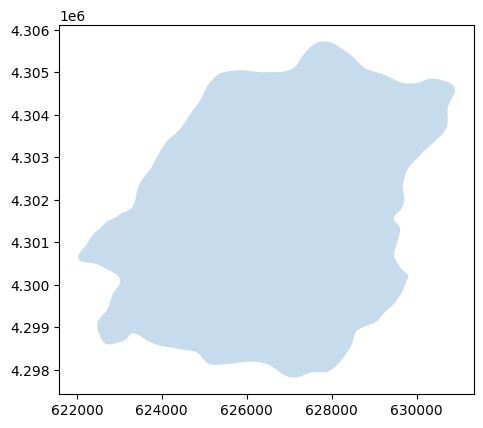

In [7]:
bounds.plot(alpha=0.25);

Dibuja sobre el terreno con contextily

In [8]:
import contextily as cx

#cx.providers

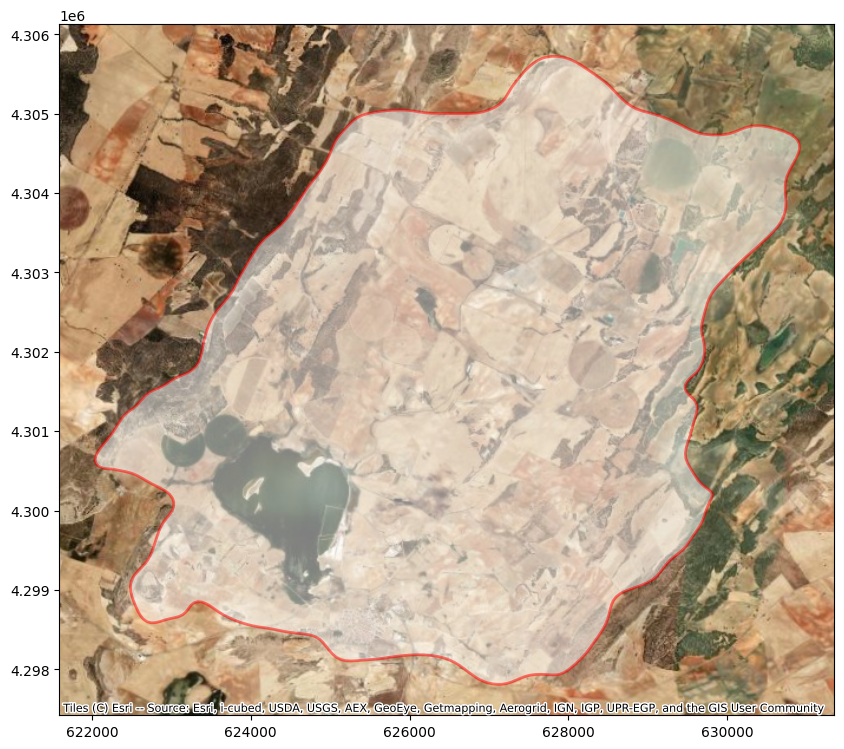

In [9]:
ax = bounds.plot(color='white', alpha=0.5, figsize=(10,10), edgecolor="red", linewidth=2)
cx.add_basemap(ax, crs=bounds.crs.to_string(), source=cx.providers.Esri.WorldImagery)

## Estaciones

In [10]:
stations = pd.read_excel('../Datos Excel/Estaciones/General.xlsx').set_index('StationID')[['X','Y']]
loc_stations = gpd.points_from_xy(stations['X'], stations['Y'])
stations = gpd.GeoDataFrame(stations, geometry=loc_stations)
stations.head()

,X,Y,geometry
StationID,,,
493,628525.0,4302550,POINT (628525 4302550)
699,619500.0,4300650,POINT (619500 4300650)
2429,631340.0,4300490,POINT (631340 4300490)
2430,619644.0,4300550,POINT (619644 4300550)
2534,622443.0,4300541,POINT (622443 4300541)


Establece el sistema de coordenadas de referencia (se utiliza también ETRS89)

In [11]:
stations = stations.set_crs('EPSG:25830')

Dibuja límites y estaciones


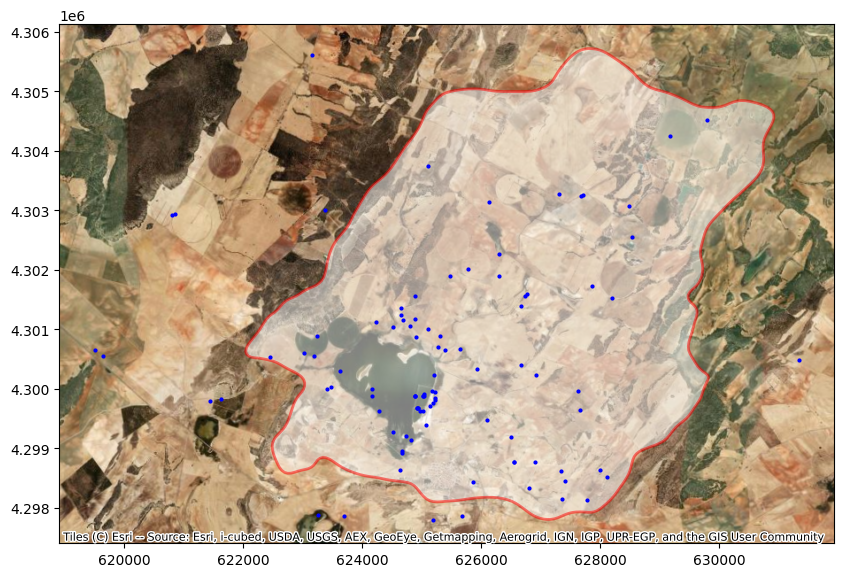

In [12]:
ax = bounds.plot(color='white', alpha=0.5, figsize=(10,10), edgecolor="red", linewidth=2)
ax = stations.plot(color='blue', markersize=4, ax=ax)
cx.add_basemap(ax, crs=bounds.crs.to_string(), source=cx.providers.Esri.WorldImagery)

Como se ve regular, lo vamos a mostrar con `Folium`, que es un *wrapper* the `Leaflet`, una de las librerías de referencia para visualización de mapas, y que está escrita en Javascript. Admite datos en formato WSG84, Lat/Long.

In [13]:
bounds_wsg84 = bounds.to_crs('EPSG:4326')
stations_wsg84 = stations.to_crs('EPSG:4326')

In [14]:
import folium

center = [38.857146, -1.5309350]
m = folium.Map(location=(center[0], center[1]), 
               tiles='Esri.WorldImagery',
               zoom_start=12)

# Añade los límites
folium.GeoJson(bounds_wsg84).add_to(m)

# Añade las localizaciones de las estaciones del excel
for idx, row in stations_wsg84.iterrows():
    point_location = [row.geometry.y, row.geometry.x]
    popup_content = f"Station ID: {idx}"
    folium.Marker(
        location=point_location,
        popup=folium.Popup(popup_content, max_width=300), 
        tooltip=f"ID: {idx}" 
    ).add_to(m)

m